# 01 - Explorative Datenanalyse

Analyse der verfügbaren Datenquellen für die PV-Optimierung:
- **evcc** (REST API): PV-Erzeugung, Batterie, Grid, Verbrauch, Ladesitzungen
- **Wetter** (Open-Meteo): Sonneneinstrahlung, Temperatur, Bewölkung
- **Strompreise** (aWATTar via evcc): Day-Ahead-Preise, negative Preise

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

from src.data.evcc_connector import get_state, get_site_power, get_sessions, get_energy_history, get_tariff
from src.data.weather_connector import get_forecast, get_historical
from src.data.price_connector import get_awattar_prices

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

## 1. Daten laden

In [11]:
# --- evcc: Energiehistorie (home = PV + Verbrauch, grid = Import/Export) ---
energy_raw = get_energy_history()
print(f"Energy History: {len(energy_raw)} Einträge, Quellen: {energy_raw['source'].unique()}")

# Home-Daten (PV + Verbrauch) – längste Historie
home = energy_raw[energy_raw["source"] == "home"].copy()
home = home.sort_values("start").reset_index(drop=True)
print(f"  home: {len(home)} Einträge, {home['start'].min()} bis {home['end'].max()}")

# Grid-Daten (Import/Export)
grid = energy_raw[energy_raw["source"].str.startswith("db:3")].copy()
grid = grid.sort_values("start").reset_index(drop=True)
print(f"  grid: {len(grid)} Einträge, {grid['start'].min()} bis {grid['end'].max()}" if len(grid) else "  grid: keine Daten")

# --- evcc: Ladesitzungen ---
sessions = get_sessions()
print(f"\nSessions: {len(sessions)} Einträge")

# --- evcc: Tarife ---
tariff_grid = get_tariff("grid")
tariff_feedin = get_tariff("feedin")
print(f"Grid-Tarif: {len(tariff_grid)} Einträge")
print(f"Feedin-Tarif: {len(tariff_feedin)} Einträge")

# --- Wetter: Historie seit frühestem evcc-Datum ---
from datetime import date, timedelta
weather_start = home["start"].min().date()
weather_end = date.today() - timedelta(days=1)
weather = get_historical(start_date=weather_start, end_date=weather_end)
print(f"\nWetter-Historie: {len(weather)} Einträge, {weather['timestamp'].min()} bis {weather['timestamp'].max()}")

Energy History: 8424 Einträge, Quellen: <StringArray>
['db:3', 'db:5', 'db:7', 'home']
Length: 4, dtype: str
  home: 7072 Einträge, 2026-02-18 17:30:00+00:00 bis 2026-05-10 18:45:00+00:00
  grid: 1347 Einträge, 2026-04-19 14:30:00+00:00 bis 2026-05-10 18:45:00+00:00

Sessions: 78 Einträge
Grid-Tarif: 768 Einträge
Feedin-Tarif: 600 Einträge

Wetter-Historie: 1944 Einträge, 2026-02-18 00:00:00 bis 2026-05-09 23:00:00


## 2. Datenqualität prüfen

In [12]:
# --- Lücken in Home-Daten ---
home["gap"] = home["start"] - home["end"].shift(1)
gaps = home[home["gap"] > pd.Timedelta(minutes=20)]
print(f"Home-Daten: {len(gaps)} Lücken > 20 Min")
if len(gaps) > 0:
    print(gaps[["start", "gap"]].head(10).to_string(index=False))

# --- Nullwerte ---
print(f"\nNullwerte Home: import={home['import'].isna().sum()}, export={home['export'].isna().sum()}")
print(f"Nullwerte Wetter:")
print(weather.isna().sum().to_string())

# --- Ausreißer-Filterung (Perzentil-basiert) ---
def filter_outliers(df, column, percentile=99.5):
    """Entfernt Ausreißer über dem angegebenen Perzentil. Gibt bereinigten DF + Info zurück."""
    thresh = df[column].quantile(percentile / 100)
    outliers = df[df[column] > thresh]
    cleaned = df[df[column] <= thresh].copy()
    return cleaned, len(outliers), thresh

print(f"\n--- Ausreißer-Filterung (99.5-Perzentil) ---")
print(f"Vor Filterung: Home={len(home)}, Grid={len(grid)}")

home, n_out, thresh = filter_outliers(home, "import")
print(f"Home import: {n_out} Ausreißer entfernt (>{thresh:.2f} kWh/15min = {thresh*4:.1f} kW)")

if len(grid) > 0:
    grid, n_imp, t_imp = filter_outliers(grid, "import")
    grid, n_exp, t_exp = filter_outliers(grid, "export")
    print(f"Grid import: {n_imp} Ausreißer entfernt (>{t_imp:.2f} kWh/15min = {t_imp*4:.1f} kW)")
    print(f"Grid export: {n_exp} Ausreißer entfernt (>{t_exp:.2f} kWh/15min = {t_exp*4:.1f} kW)")

print(f"Nach Filterung: Home={len(home)}, Grid={len(grid)}")

# --- Statistiken nach Bereinigung ---
print(f"\n--- Bereinigte Statistik ---")
print(f"Home import: mean={home['import'].mean():.4f}, max={home['import'].max():.4f} kWh/15min")
if len(grid) > 0:
    print(f"Grid import: mean={grid['import'].mean():.4f}, max={grid['import'].max():.4f} kWh/15min")
    print(f"Grid export: mean={grid['export'].mean():.4f}, max={grid['export'].max():.4f} kWh/15min")

Home-Daten: 5 Lücken > 20 Min
                    start             gap
2026-02-18 19:15:00+00:00 0 days 00:30:00
2026-02-19 13:30:00+00:00 0 days 00:30:00
2026-03-29 03:00:00+00:00 0 days 01:00:00
2026-04-12 14:00:00+00:00 0 days 00:30:00
2026-05-10 18:00:00+00:00 7 days 03:30:00

Nullwerte Home: import=0, export=0
Nullwerte Wetter:
timestamp              0
temperature_2m         0
shortwave_radiation    0
direct_radiation       0
diffuse_radiation      0
cloud_cover            0
wind_speed_10m         0

--- Ausreißer-Filterung (99.5-Perzentil) ---
Vor Filterung: Home=7072, Grid=1347
Home import: 36 Ausreißer entfernt (>1.35 kWh/15min = 5.4 kW)
Grid import: 6 Ausreißer entfernt (>2.71 kWh/15min = 10.8 kW)
Grid export: 7 Ausreißer entfernt (>2.63 kWh/15min = 10.5 kW)
Nach Filterung: Home=7036, Grid=1334

--- Bereinigte Statistik ---
Home import: mean=0.1439, max=1.3509 kWh/15min
Grid import: mean=0.0632, max=2.7100 kWh/15min
Grid export: mean=0.3990, max=2.6329 kWh/15min


## 3. Home-Verbrauch: Tages- und Wochenmuster

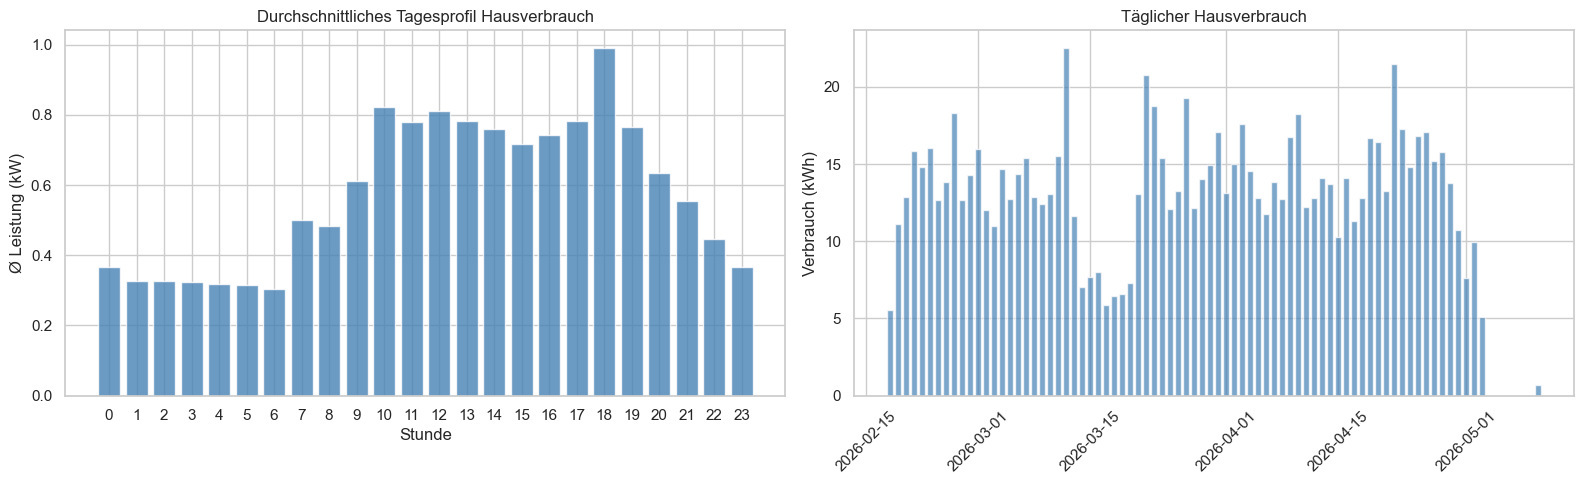

Ø Tagesverbrauch: 13.3 kWh
Min: 0.7 kWh, Max: 22.5 kWh


In [13]:
# Stündliche Aggregation des Home-Verbrauchs
home["hour"] = home["start"].dt.hour
home["weekday"] = home["start"].dt.dayofweek  # 0=Mo, 6=So
home["date"] = home["start"].dt.date

# Tagesverbrauch
daily_home = home.groupby("date")["import"].sum().reset_index()
daily_home.columns = ["date", "consumption_kwh"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tagesprofil nach Stunde
hourly = home.groupby("hour")["import"].mean() * 4  # *4 = hochrechnen auf kW (15-Min → Stundenleistung)
axes[0].bar(hourly.index, hourly.values, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Stunde")
axes[0].set_ylabel("Ø Leistung (kW)")
axes[0].set_title("Durchschnittliches Tagesprofil Hausverbrauch")
axes[0].set_xticks(range(0, 24))

# Tagesverbrauch über Zeit
axes[1].bar(daily_home["date"], daily_home["consumption_kwh"], color="steelblue", alpha=0.7)
axes[1].set_ylabel("Verbrauch (kWh)")
axes[1].set_title("Täglicher Hausverbrauch")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Ø Tagesverbrauch: {daily_home['consumption_kwh'].mean():.1f} kWh")
print(f"Min: {daily_home['consumption_kwh'].min():.1f} kWh, Max: {daily_home['consumption_kwh'].max():.1f} kWh")

## 4. Grid Import/Export (Netzeinspeisung vs. Netzbezug)

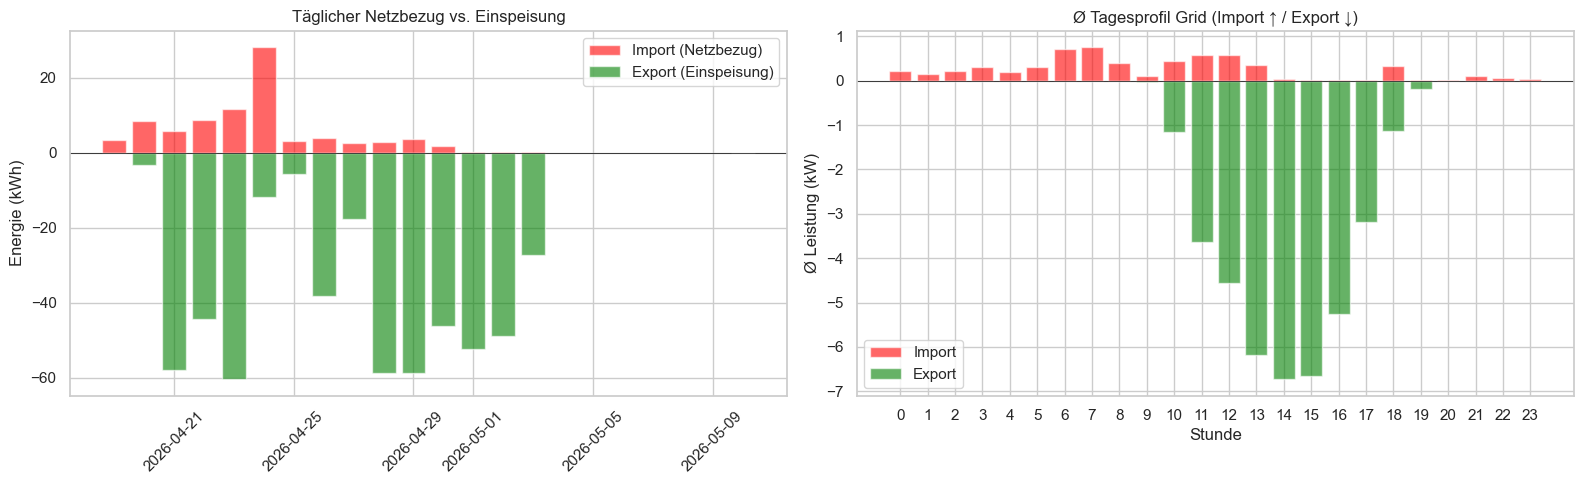

Ø täglicher Import: 5.3 kWh
Ø täglicher Export: 33.3 kWh
Eigenverbrauchsquote (grob): 13.7%


In [14]:
if len(grid) > 0:
    grid["hour"] = grid["start"].dt.hour
    grid["date"] = grid["start"].dt.date

    # Tägliche Aggregation
    daily_grid = grid.groupby("date").agg(
        import_kwh=pd.NamedAgg(column="import", aggfunc="sum"),
        export_kwh=pd.NamedAgg(column="export", aggfunc="sum"),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Täglicher Import vs. Export
    x = range(len(daily_grid))
    axes[0].bar(daily_grid["date"], daily_grid["import_kwh"], color="red", alpha=0.6, label="Import (Netzbezug)")
    axes[0].bar(daily_grid["date"], -daily_grid["export_kwh"], color="green", alpha=0.6, label="Export (Einspeisung)")
    axes[0].axhline(0, color="black", linewidth=0.5)
    axes[0].set_ylabel("Energie (kWh)")
    axes[0].set_title("Täglicher Netzbezug vs. Einspeisung")
    axes[0].legend()
    axes[0].tick_params(axis="x", rotation=45)

    # Tagesprofil Import/Export
    hourly_grid = grid.groupby("hour")[["import", "export"]].mean() * 4
    axes[1].bar(hourly_grid.index, hourly_grid["import"], color="red", alpha=0.6, label="Import")
    axes[1].bar(hourly_grid.index, -hourly_grid["export"], color="green", alpha=0.6, label="Export")
    axes[1].axhline(0, color="black", linewidth=0.5)
    axes[1].set_xlabel("Stunde")
    axes[1].set_ylabel("Ø Leistung (kW)")
    axes[1].set_title("Ø Tagesprofil Grid (Import ↑ / Export ↓)")
    axes[1].set_xticks(range(0, 24))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Ø täglicher Import: {daily_grid['import_kwh'].mean():.1f} kWh")
    print(f"Ø täglicher Export: {daily_grid['export_kwh'].mean():.1f} kWh")
    print(f"Eigenverbrauchsquote (grob): {(1 - daily_grid['export_kwh'].sum() / (daily_grid['import_kwh'].sum() + daily_grid['export_kwh'].sum())) * 100:.1f}%")
else:
    print("Keine Grid-Daten verfügbar.")

## 5. Sonneneinstrahlung & Wettermuster

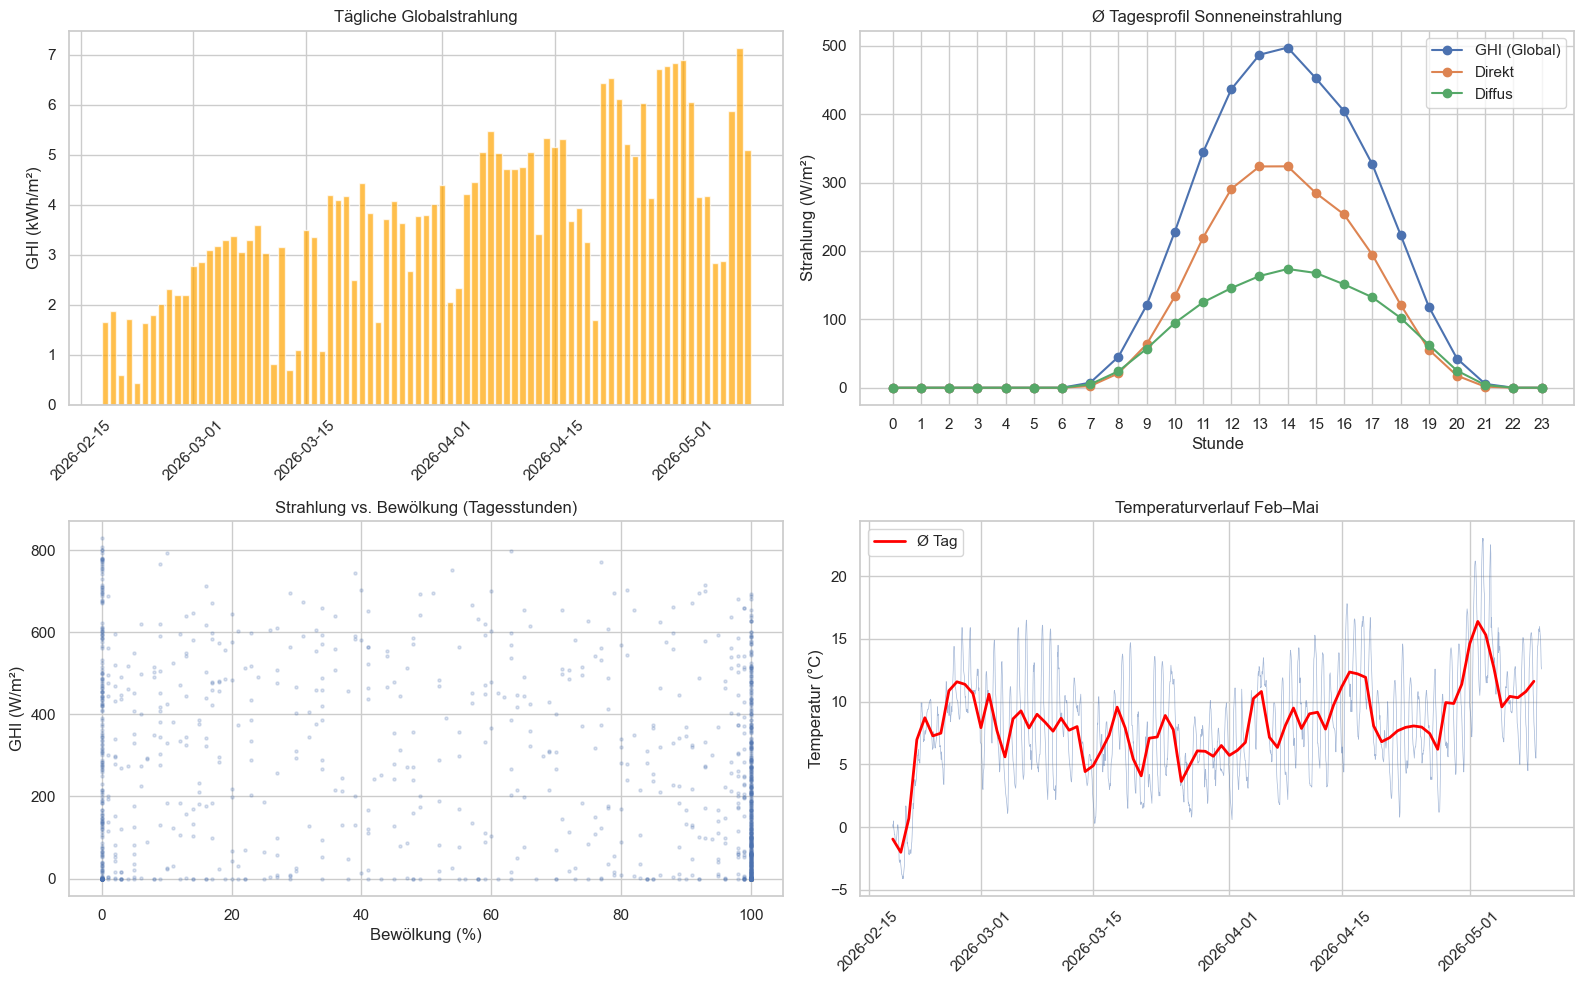

Ø tägliche GHI: 3.7 kWh/m²
Bester Tag: 2026-05-08 (7.1 kWh/m²)
Ø Temperatur: 8.2°C


In [6]:
weather["hour"] = weather.timestamp.dt.hour
weather["date"] = weather.timestamp.dt.date

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Tägliche Globalstrahlung
daily_weather = weather.groupby("date").agg(
    total_ghi_kwh=pd.NamedAgg(column="shortwave_radiation", aggfunc=lambda x: x.sum() / 1000),
    mean_cloud=pd.NamedAgg(column="cloud_cover", aggfunc="mean"),
    mean_temp=pd.NamedAgg(column="temperature_2m", aggfunc="mean"),
).reset_index()

axes[0, 0].bar(daily_weather["date"], daily_weather["total_ghi_kwh"], color="orange", alpha=0.7)
axes[0, 0].set_ylabel("GHI (kWh/m²)")
axes[0, 0].set_title("Tägliche Globalstrahlung")
axes[0, 0].tick_params(axis="x", rotation=45)

# Tagesprofil Strahlung
hourly_weather = weather.groupby("hour")[["shortwave_radiation", "direct_radiation", "diffuse_radiation"]].mean()
hourly_weather.plot(ax=axes[0, 1], marker="o")
axes[0, 1].set_xlabel("Stunde")
axes[0, 1].set_ylabel("Strahlung (W/m²)")
axes[0, 1].set_title("Ø Tagesprofil Sonneneinstrahlung")
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].legend(["GHI (Global)", "Direkt", "Diffus"])

# Strahlung vs. Bewölkung
day_hours = weather[(weather.hour >= 6) & (weather.hour <= 20)]
axes[1, 0].scatter(day_hours["cloud_cover"], day_hours["shortwave_radiation"], alpha=0.2, s=5)
axes[1, 0].set_xlabel("Bewölkung (%)")
axes[1, 0].set_ylabel("GHI (W/m²)")
axes[1, 0].set_title("Strahlung vs. Bewölkung (Tagesstunden)")

# Temperaturverlauf
axes[1, 1].plot(weather["timestamp"], weather["temperature_2m"], alpha=0.5, linewidth=0.5)
daily_temp = weather.groupby("date")["temperature_2m"].mean()
axes[1, 1].plot(daily_temp.index, daily_temp.values, color="red", linewidth=2, label="Ø Tag")
axes[1, 1].set_ylabel("Temperatur (°C)")
axes[1, 1].set_title("Temperaturverlauf Feb–Mai")
axes[1, 1].legend()
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Ø tägliche GHI: {daily_weather['total_ghi_kwh'].mean():.1f} kWh/m²")
print(f"Bester Tag: {daily_weather.loc[daily_weather['total_ghi_kwh'].idxmax(), 'date']} ({daily_weather['total_ghi_kwh'].max():.1f} kWh/m²)")
print(f"Ø Temperatur: {weather['temperature_2m'].mean():.1f}°C")

## 6. Korrelation Wettervariablen

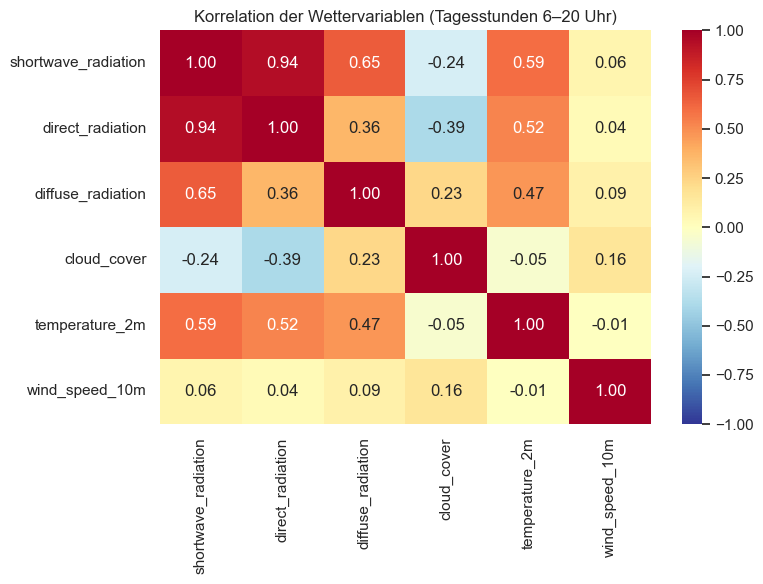

In [7]:
# Korrelation nur für Tagesstunden (6-20 Uhr)
day = weather[(weather.hour >= 6) & (weather.hour <= 20)].copy()
corr_cols = ["shortwave_radiation", "direct_radiation", "diffuse_radiation",
             "cloud_cover", "temperature_2m", "wind_speed_10m"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(day[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdYlBu_r", ax=ax, vmin=-1, vmax=1)
ax.set_title("Korrelation der Wettervariablen (Tagesstunden 6–20 Uhr)")
plt.tight_layout()
plt.show()

## 7. Strompreise (evcc Grid-Tarif + aWATTar)

Grid-Tarif: 768 Intervalle, davon 0 negativ
Preisspanne: 25.86 – 25.86 ct/kWh

Einspeisevergütung: 7.90 ct/kWh (konstant)


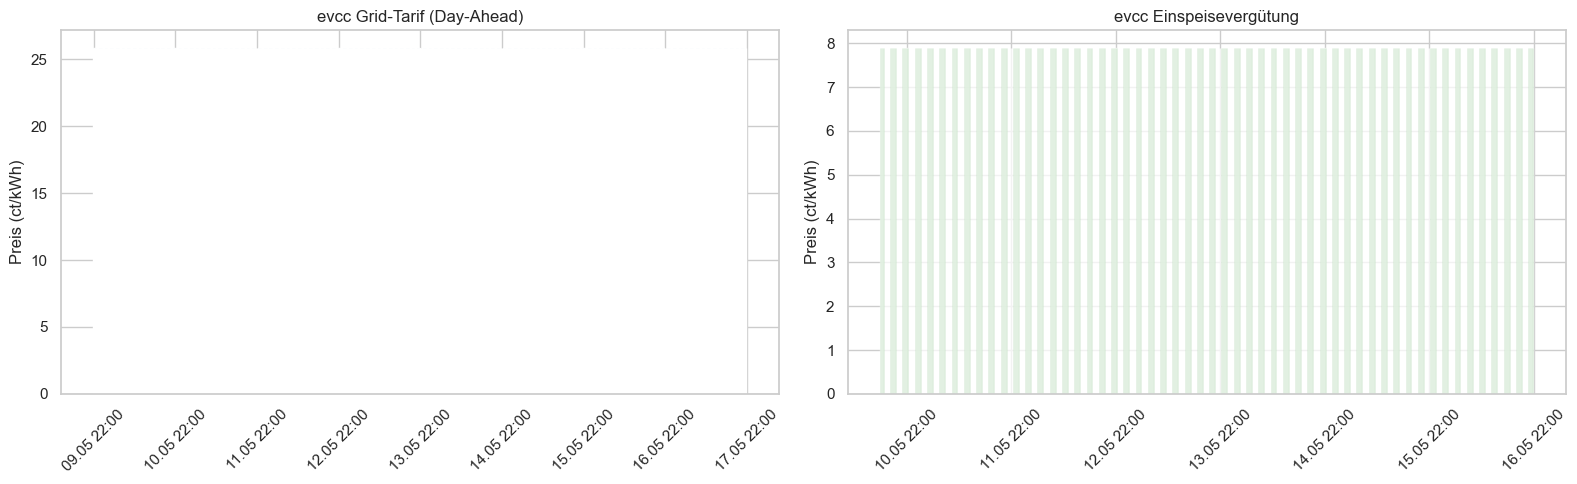

In [8]:
# Aktuelle Day-Ahead-Preise aus evcc
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# evcc Grid-Tarif (15-Min-Intervalle)
colors = ["red" if p < 0 else "steelblue" for p in tariff_grid["price"]]
axes[0].bar(tariff_grid["start"], tariff_grid["price"] * 100, color=colors, width=0.005)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Preis (ct/kWh)")
axes[0].set_title("evcc Grid-Tarif (Day-Ahead)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
axes[0].tick_params(axis="x", rotation=45)

neg_count = (tariff_grid["price"] < 0).sum()
print(f"Grid-Tarif: {len(tariff_grid)} Intervalle, davon {neg_count} negativ")
print(f"Preisspanne: {tariff_grid['price'].min()*100:.2f} – {tariff_grid['price'].max()*100:.2f} ct/kWh")

# Feedin-Tarif
axes[1].bar(tariff_feedin["start"], tariff_feedin["price"] * 100, color="green", alpha=0.7, width=0.005)
axes[1].set_ylabel("Preis (ct/kWh)")
axes[1].set_title("evcc Einspeisevergütung")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
axes[1].tick_params(axis="x", rotation=45)

print(f"\nEinspeisevergütung: {tariff_feedin['price'].mean()*100:.2f} ct/kWh (konstant)" 
      if tariff_feedin["price"].nunique() == 1 
      else f"\nEinspeisevergütung: {tariff_feedin['price'].min()*100:.2f} – {tariff_feedin['price'].max()*100:.2f} ct/kWh")

plt.tight_layout()
plt.show()

## 8. Ladesitzungen (EV)

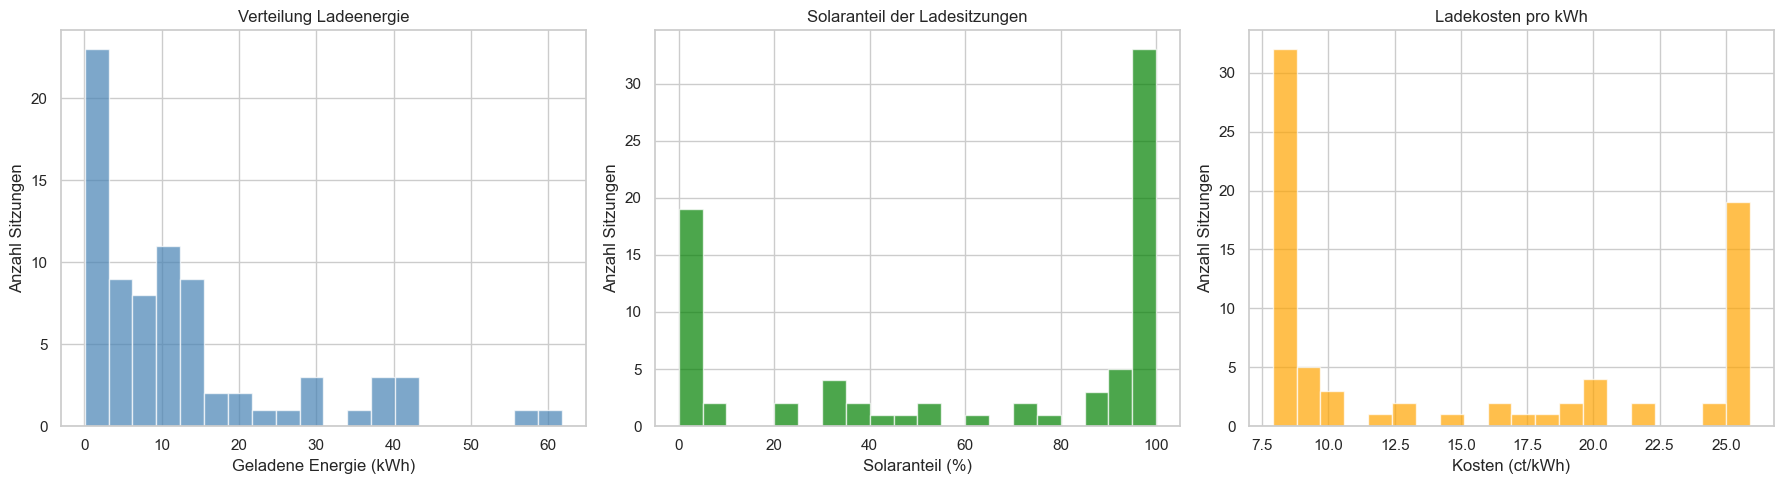

Sessions gesamt: 78
Geladene Energie: Ø 12.5 kWh, Σ 973 kWh
Solaranteil: Ø 60.5%
Ladekosten: Ø 15.1 ct/kWh
Loadpoints: ['goe-Anbau', 'Wärmepumpe', 'goe-1']


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Geladene Energie pro Sitzung
axes[0].hist(sessions["chargedEnergy"], bins=20, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].set_xlabel("Geladene Energie (kWh)")
axes[0].set_ylabel("Anzahl Sitzungen")
axes[0].set_title("Verteilung Ladeenergie")

# Solaranteil pro Sitzung
axes[1].hist(sessions["solarPercentage"], bins=20, color="green", alpha=0.7, edgecolor="white")
axes[1].set_xlabel("Solaranteil (%)")
axes[1].set_ylabel("Anzahl Sitzungen")
axes[1].set_title("Solaranteil der Ladesitzungen")

# Kosten pro kWh
axes[2].hist(sessions["pricePerKWh"] * 100, bins=20, color="orange", alpha=0.7, edgecolor="white")
axes[2].set_xlabel("Kosten (ct/kWh)")
axes[2].set_ylabel("Anzahl Sitzungen")
axes[2].set_title("Ladekosten pro kWh")

plt.tight_layout()
plt.show()

print(f"Sessions gesamt: {len(sessions)}")
print(f"Geladene Energie: Ø {sessions['chargedEnergy'].mean():.1f} kWh, Σ {sessions['chargedEnergy'].sum():.0f} kWh")
print(f"Solaranteil: Ø {sessions['solarPercentage'].mean():.1f}%")
print(f"Ladekosten: Ø {sessions['pricePerKWh'].mean()*100:.1f} ct/kWh")
print(f"Loadpoints: {sessions['loadpoint'].unique().tolist()}")

## 9. Zusammenfassung & Erkenntnisse

### Datenlage
- **Home-Verbrauch**: 7071 Datenpunkte (15-Min), ab 18.02.2026 – **gute Basis für Training**
- **Grid Import/Export**: 1346 Datenpunkte, erst ab 19.04.2026 – kürzere Historie
- **Wetter**: 1944 Stunden (81 Tage) ab Open-Meteo, passend zum evcc-Zeitraum
- **Sessions**: 78 Ladesitzungen (3 Loadpoints: 2x go-e, 1x Wärmepumpe)
- **Datenqualität**: Gut, nur 5 Lücken >20 Min, keine Nullwerte im Wetter

### Erkenntnisse
1. **Stromtarif ist Festpreis** (25,86 ct/kWh) – keine dynamischen Day-Ahead-Preise. Negative Marktpreise betreffen den Endkunden aktuell nicht direkt. Optimierung auf Eigenverbrauch hat daher höchste Priorität.
2. **Einspeisevergütung**: 7,90 ct/kWh (konstant) – Differenz zum Bezugspreis: 17,96 ct/kWh → jede selbst verbrauchte kWh spart ~18 ct
3. **Solaranteil EV-Laden**: Ø 60,5% – Potenzial zur Verbesserung durch bessere Ladeplanung
4. **Strahlungsmuster**: GHI steigt saisonal (Feb→Mai), Peak 12–14 Uhr, starke Varianz durch Bewölkung
5. **Verbrauchsmuster**: Ø 14,1 kWh/Tag, Peak um 19 Uhr (Abend), Grundlast ~0,3 kW nachts
6. **Korrelation**: GHI ↔ Direktstrahlung: 0.94 (redundant), Bewölkung ↔ GHI: -0.24 (schwächer als erwartet)

### Nächste Schritte (Phase 2)
1. Feature Engineering (Zeitfeatures, Lag, Rolling, Wetter)
2. LightGBM-Modell für PV-Ertragsprognose trainieren
3. Optimierungslogik: Ladezeitpunkte auf Sonnenstunden verschieben